In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pwlf

# ORAS5 path
base_path = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5")

# Region
LAT_MIN, LAT_MAX = 25, 45
LON_MIN, LON_MAX = -50, -30

def piecewise_variable_analysis(
    variable_token,
    variable_label,
    units,
    n_segments=2,
    start_year=1958,
    end_year=2023
):

    # Find files
    files = sorted(base_path.rglob(f"*{variable_token}*.nc"))

    print(f"\nFound {len(files)} files for {variable_label}")

    records = []

    for f in files:

        try:

            # Extract year/month
            match = re.search(
                rf"ORAS5_(\d{{4}})_(\d{{2}}).*{variable_token}",
                f.name
            )

            if match is None:
                continue

            year = int(match.group(1))
            month = int(match.group(2))

            ds = xr.open_dataset(f)

            # First variable in dataset
            var_name = list(ds.data_vars)[0]
            var = ds[var_name]

            # Remove depth dimension if present
            for depth_dim in ["deptht", "depth", "lev"]:
                if depth_dim in var.dims:
                    var = var.isel({depth_dim: 0})

            # Coordinates
            lat = ds["nav_lat"]
            lon = ds["nav_lon"]

            # Convert longitude if needed
            lon = xr.where(lon > 180, lon - 360, lon)

            # Box mask
            box_mask = (
                (lat >= LAT_MIN) & (lat <= LAT_MAX) &
                (lon >= LON_MIN) & (lon <= LON_MAX)
            )

            # Apply mask
            var_box = var.where(box_mask)

            # Convert SST to C if needed
            if variable_token == "sst":
                if float(var_box.mean(skipna=True)) > 100:
                    var_box = var_box - 273.15

            # Mean over box
            monthly_mean = float(var_box.mean(skipna=True))

            records.append({
                "year": year,
                "month": month,
                variable_label: monthly_mean
            })

        except Exception as e:
            print(f"Skipping {f.name}: {e}")

    # Dataframe
    df = pd.DataFrame(records)

    annual_df = (
        df
        .groupby("year", as_index=False)[variable_label]
        .mean()
        .sort_values("year")
    )

    annual_df = annual_df[
        (annual_df["year"] >= start_year) &
        (annual_df["year"] <= end_year)
    ]

    years_clean = annual_df["year"].values
    values_clean = annual_df[variable_label].values

    valid = ~np.isnan(values_clean)

    years_clean = years_clean[valid]
    values_clean = values_clean[valid]

    print(annual_df)
    
    # Piecewise fit
    my_pwlf = pwlf.PiecewiseLinFit(
        years_clean,
        values_clean
    )

    breakpoints = my_pwlf.fit(n_segments)

    y_hat = my_pwlf.predict(years_clean)

    print(f"\nEstimated breakpoints: {breakpoints}")

    # Slopes
    slopes = my_pwlf.slopes

    for i, s in enumerate(slopes):
        print(f"Segment {i+1} slope: {s:.5f} {units}/year")

    # Plot
    plt.figure(figsize=(12, 6))

    plt.plot(
        years_clean,
        values_clean,
        linewidth=1.5,
        label=f"Observed {variable_label}"
    )

    plt.plot(
        years_clean,
        y_hat,
        linewidth=2.5,
        label="Piecewise Linear Fit"
    )

    for bp in breakpoints[1:-1]:
        plt.axvline(
            x=bp,
            linestyle="--",
            alpha=0.8,
            label="Breakpoint"
        )

    plt.title(
        f"Piecewise Linear Regression on Annual Mean {variable_label}"
    )

    plt.xlabel("Year")

    plt.ylabel(f"{variable_label} ({units})")

    plt.grid(True, alpha=0.3)

    plt.legend()

    plt.show()

    return annual_df, my_pwlf


Found 828 files for SST
    year        SST
0   1958  20.584044
1   1959  20.410537
2   1960  20.945526
3   1961  20.938600
4   1962  20.656470
..   ...        ...
61  2019  21.102062
62  2020  21.271212
63  2021  21.413530
64  2022  21.270770
65  2023  21.454871

[66 rows x 2 columns]

Estimated breakpoints: [1958.         1971.21211298 2023.        ]
Segment 1 slope: -0.03231 °C/year
Segment 2 slope: 0.01741 °C/year


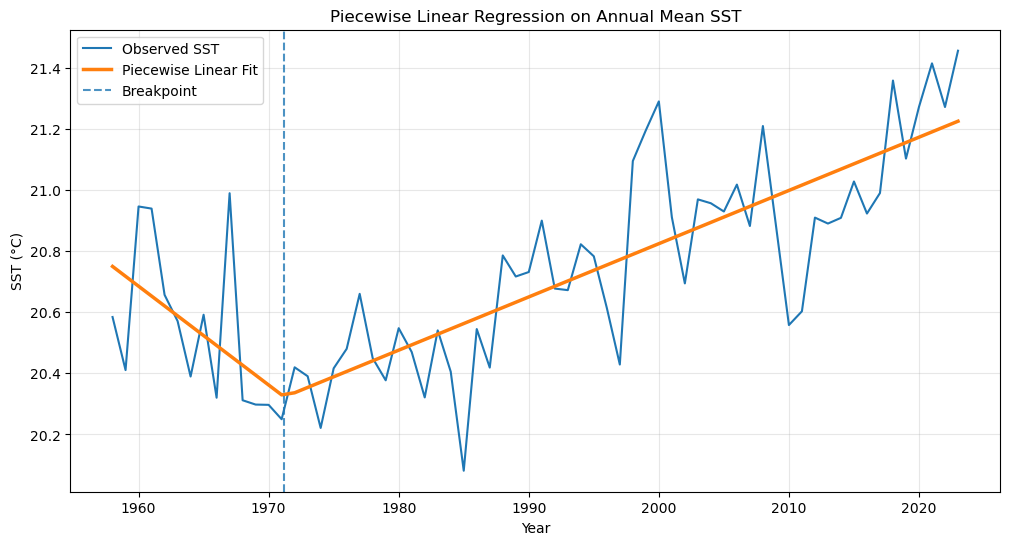


Found 775 files for Salinity
    year      Salinity
0   1958  3.633291e+01
1   1959  3.638627e+01
2   1960  3.640640e+01
3   1961  3.647224e+01
4   1962  3.645141e+01
..   ...           ...
59  2017  3.650750e+01
60  2018  3.653849e+01
61  2019  1.561957e+18
62  2020  1.593569e+18
63  2021  1.612030e+18

[64 rows x 2 columns]

Estimated breakpoints: [1958.         2017.05143323 2021.        ]
Segment 1 slope: -50264781.00000 PSU/year
Segment 2 slope: 486770025010780544.00000 PSU/year


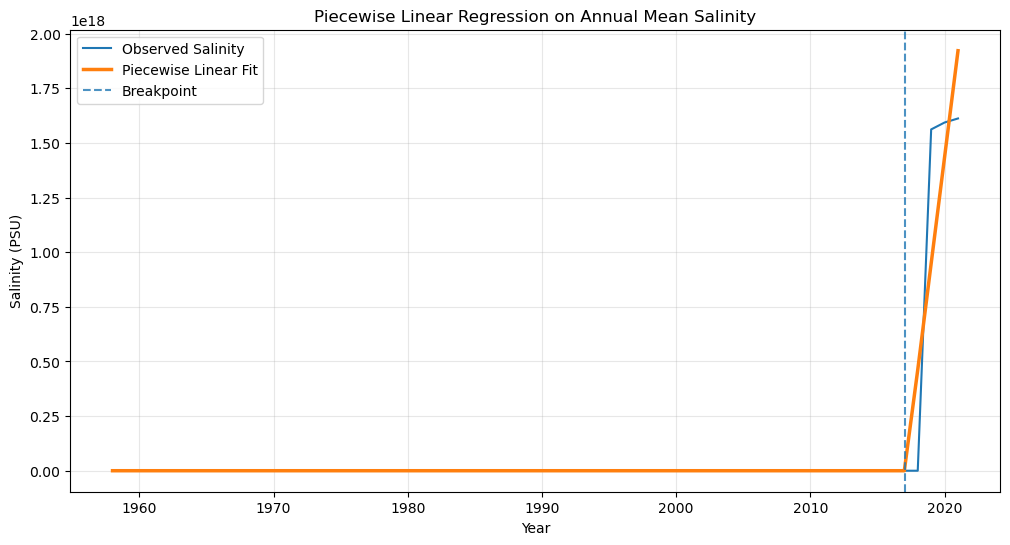


Found 778 files for V Current
Skipping ORAS5_1979_02_v_meridional_boxed.nc: "No variable named 'nav_lat'. Variables on the dataset include ['vomecrty']"
    year     V Current
0   1958 -1.437868e-03
1   1959 -2.055211e-03
2   1960 -2.936149e-03
3   1961 -2.971161e-03
4   1962 -2.157996e-03
..   ...           ...
59  2017 -2.897116e-03
60  2018 -3.810609e-03
61  2019  1.561957e+18
62  2020  1.593569e+18
63  2021  1.613304e+18

[64 rows x 2 columns]

Estimated breakpoints: [1958.         2017.05269739 2021.        ]
Segment 1 slope: -1892924517.50000 m/s/year
Segment 2 slope: 487151795835584128.00000 m/s/year


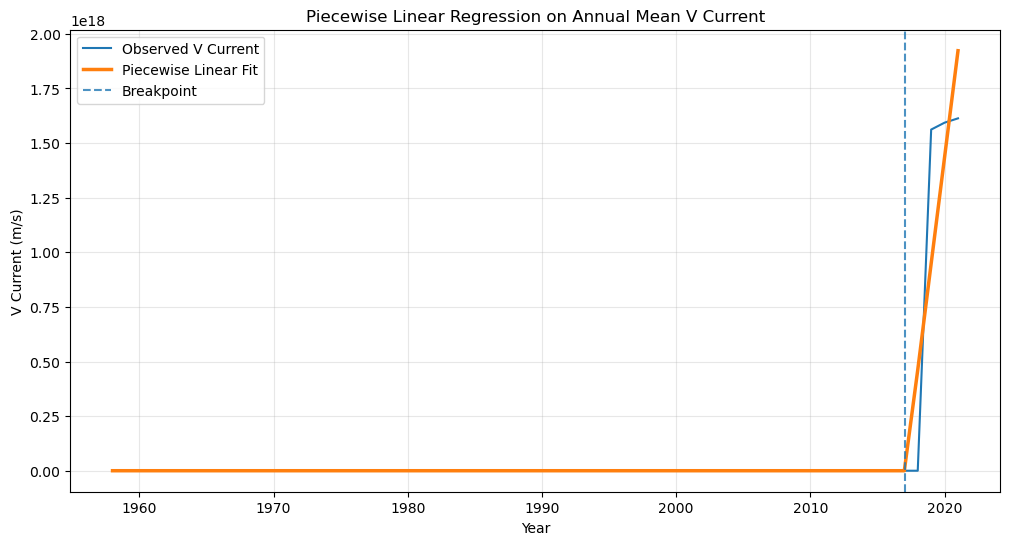

In [4]:
# SST
sst_df, sst_fit = piecewise_variable_analysis(
    variable_token="sst",
    variable_label="SST",
    units="°C"
)

# Salinity
sal_df, sal_fit = piecewise_variable_analysis(
    variable_token="so_salinity",
    variable_label="Salinity",
    units="PSU"
)

# V current
v_df, v_fit = piecewise_variable_analysis(
    variable_token="v_meridional",
    variable_label="V Current",
    units="m/s"
)

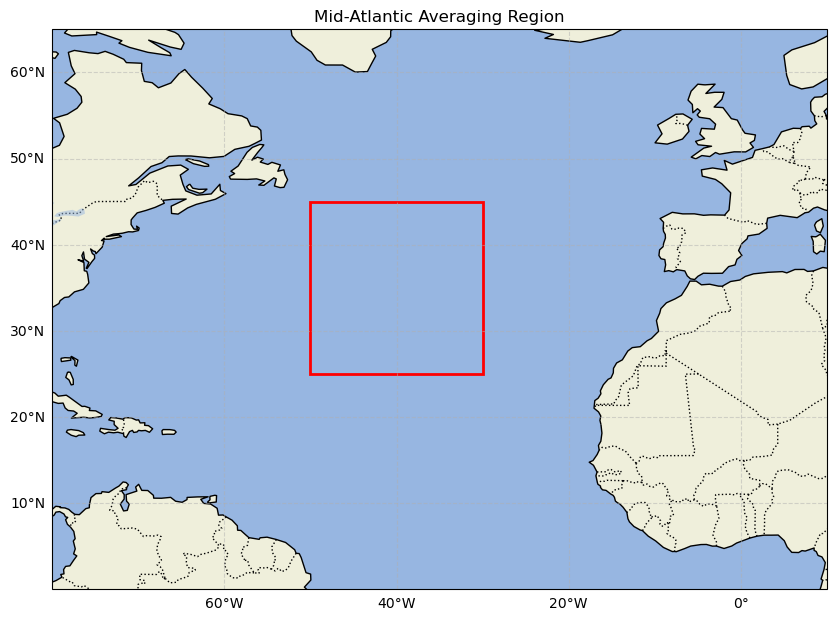

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

# Region
LAT_MIN, LAT_MAX = 25, 45
LON_MIN, LON_MAX = -50, -30

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-80, 10, 0, 65], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.LAKES, alpha=0.5)

gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

rect = Rectangle(
    (LON_MIN, LAT_MIN),
    LON_MAX - LON_MIN,
    LAT_MAX - LAT_MIN,
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    transform=ccrs.PlateCarree()
)

ax.add_patch(rect)

plt.title("Mid-Atlantic Averaging Region")
plt.show()